## 1. What this notebook computes

The request behind this chapter speaks of universes "created in pairs". Before we
can say what the equations of this book do and do not prove about that, we must be
clear what a proof of creation would contain. This notebook works it out on the
one example of pair creation that physics understands completely: an electron and
a positron (its antiparticle) made from light. It separates three questions:

- **Q1, allowed?** Do the conservation laws (energy, momentum, charge) permit the
  process? This is answered here completely, by algebra and by computation.
- **Q2, does it happen?** Is there a dynamical law that turns the initial state
  into the final one? For light this is quantum electrodynamics, which this
  notebook does NOT compute.
- **Q3, how often?** A number: a rate, a probability, a cross section. Again a
  result of the dynamics, not of the conservation laws.

It computes: the invariant mass and the inequality behind every threshold (proved
with sympy, tested on 20000 random pairs); why one photon can never make a pair;
the threshold photon energy on a nucleus, with an exact final state at the
threshold; and the allowed region for two photons. At the end it reads, from the
Revision record of the pairing theorems, which of the three questions those
theorems answer for universes: none of Q2 and Q3.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 20c (Allowed is not the same as happens: the threshold of pair creation) is the
file `Revision/textbook/notebooks/20c_allowed_not_happens.ipynb` of the repository
Dirac_claude. It computes, from the relativistic relation between energy, momentum and
mass and the conservation of energy and momentum, when the creation of an electron and a
positron from light is allowed: it proves with sympy that the invariant mass of two
bodies is at least the sum of their masses and tests it on 20000 random pairs, shows that
a single photon can never make a pair, derives the threshold photon energy 2m(1 + m/M) on
a nucleus of mass M with an exact final state at the threshold, and the allowed region
for two photons at any angle. It then reads from the Revision record what the pairing
theorems do not establish (no creation process, no rate, no amplitude), and draws four
teaching figures. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 20c_allowed_not_happens.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 20c_allowed_not_happens.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
20c_allowed_not_happens.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/20c.captions.json`
- `Revision/textbook/figures/20c_1_invariant_mass_inequality.png`
- `Revision/textbook/figures/20c_2_nucleus_threshold.png`
- `Revision/textbook/figures/20c_3_allowed_photon_energies.png`
- `Revision/textbook/figures/20c_4_two_photon_regions.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 12 CHECKS PASSED (notebook 20c)

and the notebook must show 4 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/20c_allowed_not_happens.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file below the folder Revision: the notebook reads two
  files of the repository; it must be opened inside the folder
  Revision/textbook/notebooks of a complete copy of the repository made with git clone (a
  notebook copied alone to another folder cannot find them).

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 20c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 20c (Allowed is not the same as happens: the threshold of pair creation) is
# the file Revision/textbook/notebooks/20c_allowed_not_happens.ipynb of the repository
# Dirac_claude. It computes, from the relativistic relation between energy, momentum and
# mass and the conservation of energy and momentum, when the creation of an electron and
# a positron from light is allowed: it proves with sympy that the invariant mass of two
# bodies is at least the sum of their masses and tests it on 20000 random pairs, shows
# that a single photon can never make a pair, derives the threshold photon energy 2m(1 +
# m/M) on a nucleus of mass M with an exact final state at the threshold, and the allowed
# region for two photons at any angle. It then reads from the Revision record what the
# pairing theorems do not establish (no creation process, no rate, no amplitude), and
# draws four teaching figures. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 20c_allowed_not_happens.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 20c_allowed_not_happens.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 20c_allowed_not_happens.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/20c.captions.json
# - Revision/textbook/figures/20c_1_invariant_mass_inequality.png
# - Revision/textbook/figures/20c_2_nucleus_threshold.png
# - Revision/textbook/figures/20c_3_allowed_photon_energies.png
# - Revision/textbook/figures/20c_4_two_photon_regions.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 12 CHECKS PASSED (notebook 20c)
#
# and the notebook must show 4 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/20c_allowed_not_happens.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file below the folder Revision: the notebook reads two
#   files of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository made with git clone
#   (a notebook copied alone to another folder cannot find them).
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "20c"  # this notebook: chapter 20, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 20c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Units**: the speed of light is 1, and energies, momenta and masses are
  measured in units of the electron mass $m$ (so $m = 1$ in the code).
- **Momentum** $\vec p = (p_1, p_2, p_3)$, a vector; its length is $|\vec p| =
  \sqrt{p_1^2 + p_2^2 + p_3^2}$. **Energy** $E$ of a body of mass $\mu$:
  $E = \sqrt{\mu^2 + |\vec p|^2}$ (the energy-momentum relation of special
  relativity). A **photon** (light) has $\mu = 0$, so $E = |\vec p|$.
- **Electron, positron**: two particles of the same mass $m$ and opposite
  electric charge $-1$ and $+1$. **Nucleus**: the heavy centre of an atom, mass
  $M$.
- **Conservation law**: a quantity whose total is the same before and after any
  process (here the total energy, the total momentum and the total charge).
- **Invariant mass** $\mu$ of a collection of bodies: $\mu^2 = E_{\rm tot}^2 -
  |\vec p_{\rm tot}|^2$, computed from the totals. Because the totals are
  conserved, so is $\mu$. For one body $\mu$ is its mass.
- **Threshold**: the smallest energy at which a process is allowed.
- **Allowed** (in this notebook): not forbidden by any conservation law. Allowed
  does not mean that the process happens, nor how often.
- **Rate, cross section, amplitude**: numbers that say how often a process
  happens; they come from a dynamical theory.
- **Lemma, proposition**: a proved statement (a lemma is a step towards others).

## 4. The physical and mathematical situation

**ASSUMED (standard physics of special relativity):** each body has $E^2 =
\mu^2 + |\vec p|^2$; the total energy and the total momentum of an isolated system
do not change; nor does its total electric charge. Everything else is derived and
computed here.

**The rule of every threshold.** A process A $\to$ B is forbidden if any conserved
quantity has different values in A and in B. Since $\mu^2$ is built from conserved
totals, $\mu_A = \mu_B$ is NECESSARY. The lemma of section 5 says that a final
state made of bodies with masses $\mu_1, \mu_2, \dots$ always has $\mu_B \geq \mu_1
+ \mu_2 + \cdots$. So the initial state must bring at least that much invariant
mass:

$$\mu_A \;\geq\; \text{(sum of the final masses)}.$$

This is a necessary condition only. Whether the process then happens, and how
often, is decided by the dynamics.

## 5. The lemma: two bodies have at least the sum of their masses

**Lemma.** Two bodies with masses $\mu_1, \mu_2 \geq 0$, momenta $\vec p_1,
\vec p_2$ and energies $E_i = \sqrt{\mu_i^2 + |\vec p_i|^2}$ have together
$(E_1 + E_2)^2 - |\vec p_1 + \vec p_2|^2 \geq (\mu_1 + \mu_2)^2$.

*Proof, line by line.* Write $a = |\vec p_1|$, $b = |\vec p_2|$.

1. Multiply out the squares: $(E_1 + E_2)^2 - |\vec p_1 + \vec p_2|^2 =
   (E_1^2 - a^2) + (E_2^2 - b^2) + 2(E_1E_2 - \vec p_1\cdot\vec p_2)$.
2. Use $E_i^2 - |\vec p_i|^2 = \mu_i^2$: this is $\mu_1^2 + \mu_2^2 +
   2(E_1E_2 - \vec p_1\cdot\vec p_2)$.
3. The dot product is at most the product of the lengths, $\vec p_1\cdot\vec p_2
   \leq ab$, so it suffices to show $E_1E_2 \geq \mu_1\mu_2 + ab$.
4. Both sides are not negative, so compare their squares:
   $E_1^2E_2^2 - (\mu_1\mu_2 + ab)^2 = (\mu_1^2 + a^2)(\mu_2^2 + b^2) -
   (\mu_1\mu_2 + ab)^2$.
5. Multiplying out, the terms $\mu_1^2\mu_2^2$ and $a^2b^2$ cancel and what remains
   is $\mu_1^2b^2 + \mu_2^2a^2 - 2\mu_1\mu_2ab = (\mu_1b - \mu_2a)^2 \geq 0$.
6. Hence $E_1E_2 - \vec p_1\cdot\vec p_2 \geq \mu_1\mu_2$, and line 2 is at least
   $\mu_1^2 + \mu_2^2 + 2\mu_1\mu_2 = (\mu_1 + \mu_2)^2$. QED.

The next cell checks line 5 with sympy, then tests the lemma on 20000 random
pairs of bodies (random masses between 0 and 3, random momenta, fixed seed).

In [2]:
import numpy as np  # arrays and random numbers
import sympy as sp  # exact algebra

mu1, mu2, a, b = sp.symbols("mu1 mu2 a b", nonnegative=True)
E1_sq, E2_sq = mu1 ** 2 + a ** 2, mu2 ** 2 + b ** 2  # E_i^2 = mu_i^2 + |p_i|^2
line5 = sp.expand(E1_sq * E2_sq - (mu1 * mu2 + a * b) ** 2)
check(sp.expand(line5 - (mu1 * b - mu2 * a) ** 2) == 0,
      "line 5: E1^2 E2^2 - (mu1 mu2 + a b)^2 = (mu1 b - mu2 a)^2")


def invariant_mass(energies, momenta):
    """mu = sqrt(E_tot^2 - |p_tot|^2) of a collection of bodies."""
    E_total = np.sum(energies, axis=0)
    p_total = np.sum(momenta, axis=0)
    return np.sqrt(np.maximum(E_total ** 2 - np.sum(p_total ** 2, axis=-1), 0.0))


rng = np.random.default_rng(20261007)  # fixed seed: the same numbers every run
count = 20000
masses = rng.uniform(0.0, 3.0, size=(2, count))  # mu1, mu2
momenta = rng.normal(size=(2, count, 3)) * rng.uniform(0.0, 4.0, size=(2, count, 1))
energies = np.sqrt(masses ** 2 + np.sum(momenta ** 2, axis=-1))
mu_total = invariant_mass(energies, momenta)
margin = mu_total - masses.sum(axis=0)  # must never be negative
report("smallest margin mu_total - (mu1 + mu2) in 20000 pairs",
       f"{margin.min():.2e}")
check(margin.min() > -1e-12, "the lemma holds for all 20000 random pairs")

PASS line 5: E1^2 E2^2 - (mu1 mu2 + a b)^2 = (mu1 b - mu2 a)^2
RESULT smallest margin mu_total - (mu1 + mu2) in 20000 pairs = 2.34e-04
PASS the lemma holds for all 20000 random pairs


The next cell draws the 20000 pairs: the invariant mass of the pair against the
sum of the two masses. Every point lies on or above the diagonal; points on the
diagonal are pairs whose bodies move together (equal velocities, the equality case
$\mu_1b = \mu_2a$ of line 5 with parallel momenta).

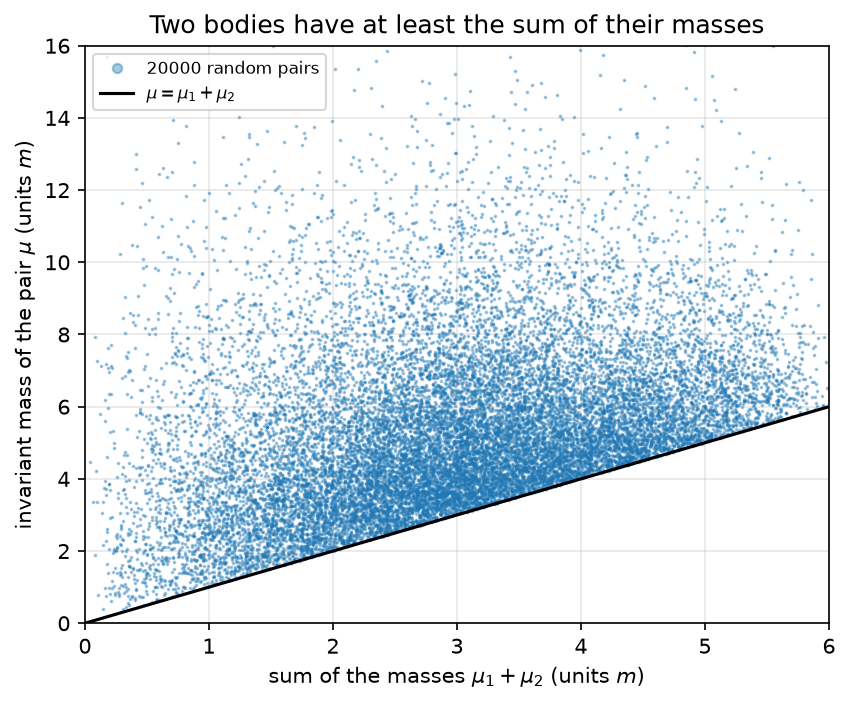

Figure 20c.1 saved as Revision/textbook/figures/20c_1_invariant_mass_inequality.png


In [3]:
fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.plot(masses.sum(axis=0), mu_total, ".", markersize=1.5, alpha=0.4,
        color="tab:blue", label="20000 random pairs")
ax.plot([0, 6], [0, 6], color="black", linewidth=1.5,
        label="$\\mu = \\mu_1 + \\mu_2$")
ax.set_xlabel("sum of the masses $\\mu_1 + \\mu_2$ (units $m$)")
ax.set_ylabel("invariant mass of the pair $\\mu$ (units $m$)")
ax.set_xlim(0, 6)
ax.set_ylim(0, 16)
ax.set_title("Two bodies have at least the sum of their masses")
ax.legend(fontsize=8, loc="upper left", markerscale=6)
save_figure(fig, "invariant_mass_inequality",
            "The invariant mass "
            "$\\mu = \\sqrt{E_{\\rm tot}^2 - |\\vec p_{\\rm tot}|^2}$ of 20000 random "
            "pairs of bodies (vertical) against the sum of their "
            "masses $\\mu_1 + \\mu_2$ (horizontal), both in units of the electron "
            "mass $m$; masses between 0 and 3, random momenta, fixed seed. Every "
            "point lies on or above the black diagonal $\\mu = \\mu_1 + \\mu_2$, as "
            "the lemma proves: a final state of bodies with given masses needs at "
            "least the sum of those masses as invariant mass, which is the origin "
            "of every threshold.")

## 6. One photon can never make a pair

**Proposition.** A single photon in empty space cannot turn into an electron and
a positron. *Proof.* Before: one photon, $\mu_A^2 = E^2 - |\vec p|^2 = 0$. After:
two bodies of mass $m$, so by the lemma $\mu_B \geq 2m > 0$. The invariant mass is
conserved, so $0 \geq 2m$, which is false. QED.

Charge does not forbid it ($-1 + 1 = 0$, the photon's charge), and energy alone
does not either (the photon may have any energy): the COMBINATION of energy and
momentum forbids it. The next cell checks the statement on 5000 random final
states: none has invariant mass zero; the smallest is $2m$.

In [4]:
pair_momenta = rng.normal(size=(2, 5000, 3)) * 3.0  # electron and positron
pair_energies = np.sqrt(1.0 + np.sum(pair_momenta ** 2, axis=-1))  # m = 1
pair_mu = invariant_mass(pair_energies, pair_momenta)
report("smallest invariant mass of 5000 electron-positron states",
       f"{pair_mu.min():.4f}")
check(pair_mu.min() >= 2.0 - 1e-12, "every electron-positron state has mu >= 2 m > 0")

RESULT smallest invariant mass of 5000 electron-positron states = 2.0003
PASS every electron-positron state has mu >= 2 m > 0


## 7. A photon on a nucleus: the threshold

A photon of energy $E_\gamma$ hits a nucleus of mass $M$ at rest; the final state
is an electron, a positron and the nucleus. Line by line:

1. Before: total energy $E_\gamma + M$, total momentum of length $E_\gamma$ (the
   photon's), so $\mu_A^2 = (E_\gamma + M)^2 - E_\gamma^2 = M^2 + 2E_\gamma M$.
2. After: by the lemma (applied twice) $\mu_B \geq m + m + M$.
3. Conservation, $\mu_A = \mu_B$, therefore needs $M^2 + 2E_\gamma M \geq
   (2m + M)^2 = M^2 + 4mM + 4m^2$.
4. Subtract $M^2$ and divide by $2M$: $E_\gamma \geq 2m + 2m^2/M =
   2m(1 + m/M)$.

At exactly the threshold the three final bodies move together with the common
velocity $v = p_{\rm tot}/E_{\rm tot}$ (the equality case of the lemma). For
$M = 4m$: $E_\gamma = 5m/2$, $p_{\rm tot} = 5m/2$, $E_{\rm tot} = 13m/2$,
$\mu = 6m$, and each body carries the share $\mu_i/\mu$ of the momentum: $5m/12$
for the electron and for the positron, $5m/3$ for the nucleus. The next cell
solves line 3 with sympy, checks this final state EXACTLY (energies and momenta
add up to the initial ones), and computes the threshold for three nuclei: $M =
4m$ (helium-like), $1000m$ and $1836m$ (about a proton).

In [5]:
E_gamma, M_nuc, m_e = sp.symbols("E_gamma M m", positive=True)
mu_initial_sq = (E_gamma + M_nuc) ** 2 - E_gamma ** 2  # line 1
threshold = sp.solve(sp.Eq(mu_initial_sq, (2 * m_e + M_nuc) ** 2), E_gamma)[0]
say(f"threshold photon energy: {sp.factor(threshold)}")
check(sp.simplify(threshold - 2 * m_e * (1 + m_e / M_nuc)) == 0,
      "E_threshold = 2 m (1 + m/M)")
M4 = 4  # the nucleus of mass 4 m, with m = 1
E_th = threshold.subs({m_e: 1, M_nuc: M4})  # 5/2
p_total, E_total = E_th, E_th + M4  # the initial totals
mu_final = sp.Integer(2 + M4)  # 6 m
shares = [1, 1, M4]  # electron, positron, nucleus masses
p_parts = [sp.Rational(mass) * p_total / mu_final for mass in shares]
E_parts = [sp.sqrt(mass ** 2 + p ** 2) for mass, p in zip(shares, p_parts)]
say(f"final state at threshold: momenta {p_parts}, energies {E_parts}")
check(sum(p_parts) == p_total and sp.simplify(sum(E_parts) - E_total) == 0
      and E_th == sp.Rational(5, 2),
      "M = 4 m: the threshold state conserves energy and momentum exactly")
for M_value in (4, 1000, 1836):
    value = threshold.subs({m_e: 1, M_nuc: M_value})
    report(f"threshold for M = {M_value} m", f"{sp.nsimplify(value)} = "
           f"{float(value):.6f} m")
check(threshold.subs({m_e: 1, M_nuc: 1836}) == 2 + sp.Rational(2, 1836),
      "M = 1836 m: the threshold is 2 m + 2 m/1836, just above 2 m")

threshold photon energy: 2*m*(M + m)/M
PASS E_threshold = 2 m (1 + m/M)
final state at threshold: momenta [5/12, 5/12, 5/3], energies [13/12, 13/12, 13/3]
PASS M = 4 m: the threshold state conserves energy and momentum exactly
RESULT threshold for M = 4 m = 5/2 = 2.500000 m
RESULT threshold for M = 1000 m = 1001/500 = 2.002000 m
RESULT threshold for M = 1836 m = 1837/918 = 2.001089 m
PASS M = 1836 m: the threshold is 2 m + 2 m/1836, just above 2 m


The next cell draws the threshold $E_\gamma/m = 2(1 + m/M)$ against the nucleus
mass $M/m$ on a logarithmic axis: a light nucleus needs much more than the two rest
energies $2m$, a heavy one takes up the momentum and almost no energy.

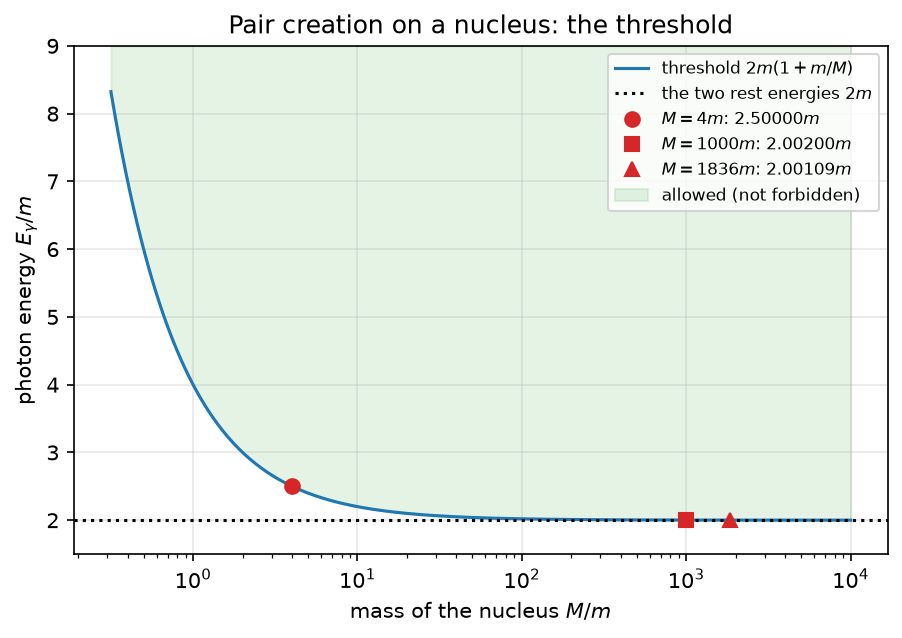

Figure 20c.2 saved as Revision/textbook/figures/20c_2_nucleus_threshold.png


In [6]:
M_axis = np.logspace(-0.5, 4, 400)  # M/m from about 0.3 to 10000
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.semilogx(M_axis, 2 * (1 + 1 / M_axis), color="tab:blue",
            label="threshold $2m(1 + m/M)$")
ax.axhline(2.0, color="black", linestyle=":", label="the two rest energies $2m$")
for M_value, marker in ((4, "o"), (1000, "s"), (1836, "^")):
    ax.plot([M_value], [2 * (1 + 1 / M_value)], marker, color="tab:red",
            markersize=7, label=f"$M = {M_value}m$: {2 * (1 + 1 / M_value):.5f}$m$")
ax.fill_between(M_axis, 2 * (1 + 1 / M_axis), 9.0, color="tab:green", alpha=0.12,
                label="allowed (not forbidden)")
ax.set_ylim(1.5, 9.0)
ax.set_xlabel("mass of the nucleus $M/m$")
ax.set_ylabel("photon energy $E_\\gamma/m$")
ax.set_title("Pair creation on a nucleus: the threshold")
ax.legend(fontsize=8, loc="upper right")
save_figure(fig, "nucleus_threshold",
            "The smallest photon energy $E_\\gamma$ (vertical, units of the "
            "electron mass $m$) at which energy and momentum conservation allow a "
            "photon hitting a nucleus of mass $M$ (horizontal, logarithmic, units "
            "$m$) to make an electron-positron pair: $E_\\gamma = 2m(1 + m/M)$ "
            "(blue). Above it (green) the process is allowed, below it forbidden. "
            "Red markers: $M = 4m$ ($2.5m$), $1000m$ ($2.002m$) and $1836m$, about "
            "a proton ($2.00109m$). For heavy nuclei the threshold approaches the "
            "two rest energies $2m$ (dotted). The curve says nothing about how "
            "often the process happens above the threshold.")

The next cell shows the same threshold as a comparison of two curves for $M =
4m$: the invariant mass the initial state brings, $\mu_A = \sqrt{M^2 +
2E_\gamma M}$, rises with the photon energy; the invariant mass the final state
needs at least is the constant $2m + M = 6m$. They cross at $E_\gamma = 5m/2$.

RESULT crossing of the two curves (M = 4 m) = 2.50 m
PASS the curves cross at E_gamma = 2.5 m


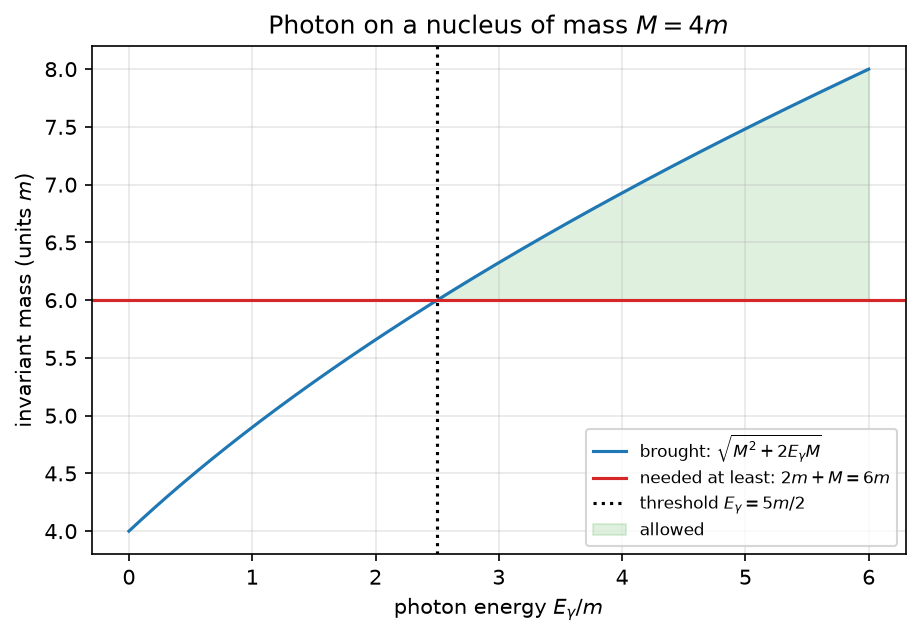

Figure 20c.3 saved as Revision/textbook/figures/20c_3_allowed_photon_energies.png


In [7]:
E_axis = np.linspace(0.0, 6.0, 601)
brought = np.sqrt(M4 ** 2 + 2 * E_axis * M4)  # mu_A for M = 4 m
crossing = E_axis[np.argmin(np.abs(brought - (2 + M4)))]
report("crossing of the two curves (M = 4 m)", f"{crossing:.2f} m")
check(abs(crossing - 2.5) < 0.01, "the curves cross at E_gamma = 2.5 m")
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(E_axis, brought, color="tab:blue", label="brought: $\\sqrt{M^2 + 2E_\\gamma M}$")
ax.axhline(2 + M4, color="tab:red", label="needed at least: $2m + M = 6m$")
ax.axvline(2.5, color="black", linestyle=":", label="threshold $E_\\gamma = 5m/2$")
ax.fill_between(E_axis, 2 + M4, brought, where=brought >= 2 + M4,
                color="tab:green", alpha=0.15, label="allowed")
ax.set_xlabel("photon energy $E_\\gamma/m$")
ax.set_ylabel("invariant mass (units $m$)")
ax.set_title("Photon on a nucleus of mass $M = 4m$")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "allowed_photon_energies",
            "For a photon hitting a nucleus of mass $M = 4m$ at rest: the invariant "
            "mass the initial state brings, $\\sqrt{M^2 + 2E_\\gamma M}$ (blue), "
            "and the smallest invariant mass the final state of electron, positron "
            "and nucleus needs, $2m + M = 6m$ (red), against the photon energy "
            "$E_\\gamma$ (horizontal; all in units of the electron mass $m$). "
            "Conservation of energy and momentum allows the pair only where the "
            "blue curve is at or above the red line (green), from the threshold "
            "$E_\\gamma = 5m/2$ (dotted) on.")

## 8. Two photons

Two photons of energies $E_a$ and $E_b$ meet at the angle $\theta$ between their
directions. Line by line: $\mu^2 = (E_a + E_b)^2 - |\vec p_a + \vec p_b|^2$;
multiplying out with $|\vec p_a| = E_a$, $|\vec p_b| = E_b$ and $\vec p_a\cdot\vec
p_b = E_aE_b\cos\theta$ gives $\mu^2 = 2E_aE_b(1 - \cos\theta)$. The lemma requires
$\mu \geq 2m$, so the pair is allowed exactly when

$$E_aE_b \;\geq\; \frac{2m^2}{1 - \cos\theta}.$$

Head on ($\theta = 180$ degrees, $\cos\theta = -1$) this is $E_aE_b \geq m^2$; for
photons moving in the same direction ($\theta = 0$) never. The next cell checks
the formula with sympy and draws the allowed regions for three angles.

PASS two photons: mu^2 = 2 E_a E_b (1 - cos theta)
PASS head on mu^2 = 4 E_a E_b; same direction mu^2 = 0 (never allowed)


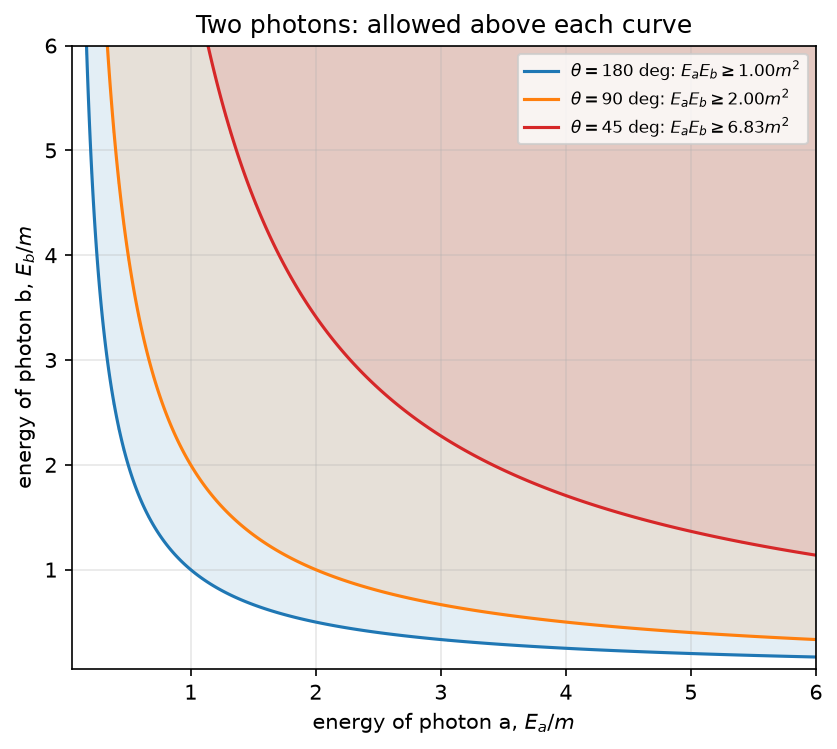

Figure 20c.4 saved as Revision/textbook/figures/20c_4_two_photon_regions.png


In [8]:
Ea, Eb, theta = sp.symbols("E_a E_b theta", positive=True)
pa = sp.Matrix([Ea, 0, 0])  # photon a along the first axis
pb = sp.Matrix([Eb * sp.cos(theta), Eb * sp.sin(theta), 0])  # photon b at angle
mu_sq = sp.simplify((Ea + Eb) ** 2 - (pa + pb).dot(pa + pb))
check(sp.simplify(mu_sq - 2 * Ea * Eb * (1 - sp.cos(theta))) == 0,
      "two photons: mu^2 = 2 E_a E_b (1 - cos theta)")
check(sp.simplify(mu_sq.subs(theta, sp.pi) - 4 * Ea * Eb) == 0
      and mu_sq.subs(theta, 0) == 0,
      "head on mu^2 = 4 E_a E_b; same direction mu^2 = 0 (never allowed)")
grid = np.linspace(0.05, 6.0, 300)
EA, EB = np.meshgrid(grid, grid)
fig, ax = plt.subplots(figsize=(6.4, 5.4))
for degrees, colour in ((180, "tab:blue"), (90, "tab:orange"), (45, "tab:red")):
    bound = 2.0 / (1 - np.cos(np.radians(degrees)))  # E_a E_b >= bound (m = 1)
    ax.contourf(EA, EB, (EA * EB >= bound).astype(float), levels=[0.5, 1.5],
                colors=[colour], alpha=0.12)
    ax.contour(EA, EB, EA * EB, levels=[bound], colors=[colour])
    ax.plot([], [], color=colour,
            label=f"$\\theta = {degrees}$ deg: $E_aE_b \\geq {bound:.2f}m^2$")
ax.set_xlabel("energy of photon a, $E_a/m$")
ax.set_ylabel("energy of photon b, $E_b/m$")
ax.set_title("Two photons: allowed above each curve")
ax.legend(fontsize=8, loc="upper right")
save_figure(fig, "two_photon_regions",
            "Two photons of energies $E_a$ and $E_b$ (horizontal and vertical, "
            "units of the electron mass $m$) meeting at the angle $\\theta$: an "
            "electron-positron pair is allowed above the curve $E_aE_b = "
            "2m^2/(1 - \\cos\\theta)$ (shaded), drawn for head-on photons, "
            "$\\theta = 180$ degrees (blue, $E_aE_b \\geq m^2$), for $90$ degrees "
            "(orange, $2m^2$) and $45$ degrees (red, about $6.83m^2$). The smaller "
            "the angle, the more energy is needed; photons moving in the same "
            "direction can never make a pair.")

## 9. What the conservation laws cannot say, and what this means for universes

Sections 5 to 8 answered Q1 completely for light: below a threshold the process
is forbidden, above it allowed. They say NOTHING about Q2 and Q3. That pairs are
really made above the threshold, and how often, was computed from quantum
electrodynamics, the dynamical theory of electrons and light, by Bethe and Heitler
(H. Bethe and W. Heitler, Proc. R. Soc. Lond. A 146, 83 (1934)) for a photon on a
nucleus and by Breit and Wheeler (G. Breit and J. A. Wheeler, Phys. Rev. 46, 1087
(1934)) for two photons. This notebook quotes these works; it does not compute
their results.

For universes of masses $+m$ and $-m$ the theory of this book supplies:

- **Q1, conserved quantities.** Light: energy, momentum and charge. Universes:
  the U(1) charge of each universe is conserved (PROVED in the record); the energy
  of a universe is NOT a conserved quantity, because the deflating metric depends
  on the time $x_4$ (for a homogeneous source the record's identity is
  $d\rho/dx_4 = -3a_4'(p_3 - p_t)$).
- **Q1, interaction.** Light couples to electrons. No term of any Lagrangian of
  the record couples two universes.
- **Q2, the dynamics of creation.** Light: quantum electrodynamics. Universes:
  none; no creation process is derived.
- **Q3, rate and amplitude.** Light: computed in 1934. Universes: none; no rate,
  probability or amplitude.

One consequence can be drawn in two lines from the record's conservation law
(status: derived here; ASSUMED: the boundary terms vanish, e.g. periodic
coordinates). Each universe obeys its own field equation and nothing couples the
two, so the charge $Q_+$ of the first universe is conserved on its own. If both
fields were zero at some time, $Q_+$ would be zero at every time. A T1 pair whose
members carry the charges $Q$ and $-Q$ with $Q \neq 0$ can therefore not evolve
out of zero fields in the theory as built: the zero TOTAL charge of a T1 pair does
not make its appearance allowed, because the separate charges are conserved too.

The next cell reads the record's own list of what the pairing theorems do not
establish and checks that it names the missing answers to Q2 and Q3.

In [9]:
theory = json.loads(repository_file("Revision/pairing/pairing-theory.json")
                    .read_text(encoding="utf-8"))
missing = theory["not_established"]  # the record's list
say(f"the record lists {len(missing)} things the pairing theorems do not establish;")
for item in missing[:3]:
    say("- " + item.split(":")[0] + ": " + item.split(":")[1].split(";")[0].strip())
starts = [item.split(":")[0] for item in missing]
check({"No creation process", "No rate and no amplitude",
       "No dynamical necessity"} <= set(starts),
      "the record states: no creation process, no rate or amplitude, no necessity")
u1 = json.loads(repository_file(
    "Revision/lead_checks/reports/charge-conjugation-and-u1.json")
    .read_text(encoding="utf-8"))
verdicts = {entry["name"]: entry["verdict"] for entry in u1["checks"]}
check(verdicts.get("u1_noether_matrix_identity") == "PASS",
      "the record proves the U(1) charge conservation of one universe",
      record="Revision/lead_checks/reports/charge-conjugation-and-u1.json, check "
             "u1_noether_matrix_identity")

the record lists 9 things the pairing theorems do not establish;
- No creation process: the theorems map solutions to solutions and quantities to
    quantities
- No rate and no amplitude: no transition amplitude, probability, cross-section, rate or
    Bogoliubov coefficient for creating universes of masses {+m, -m} is computed or
    implied.
- No dynamical necessity: nothing forces the partner configuration to exist or to be
    realised
PASS the record states: no creation process, no rate or amplitude, no necessity
PASS the record proves the U(1) charge conservation of one universe
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    u1_noether_matrix_identity


## 10. The last check

The last cell checks that the four figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [10]:
figure_names = ["invariant_mass_inequality", "nucleus_threshold",
                "allowed_photon_energies", "two_photon_regions"]
paths = [output_file(f"{FIGURE_FOLDER}/20c_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 12 CHECKS PASSED (notebook 20c)


## 11. What this notebook showed

- The invariant mass of two bodies is at least the sum of their masses (PROVED
  with sympy, and true for 20000 random pairs); this is the origin of every
  threshold (figure 1).
- One photon can never make an electron-positron pair; on a nucleus of mass $M$
  the photon needs at least $2m(1 + m/M)$: $2.5m$ for $M = 4m$, $2.00109m$ for
  $M = 1836m$, with an exact final state at the threshold (figures 2 and 3); two
  photons need $E_aE_b \geq 2m^2/(1 - \cos\theta)$ (figure 4).
- These are answers to Q1 only (allowed or forbidden). That the process happens,
  and how often, needs a dynamical theory (quantum electrodynamics, quoted, not
  computed).
- For universes the record has conservation laws but no interaction between
  universes, no creation process, no rate and no amplitude: Q2 and Q3 are not
  answered, and with separately conserved charges a T1 pair with nonzero charges
  cannot evolve out of zero fields in the theory as built.